# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Demo Notebook: Audience-Centric Design & Visualization Ethics

topics:

1. Audience-Centric Visualization & Understanding the Audience
2. Designing for the Audience's Task & Directing Attention
3. Strategic Highlighting
4. Annotation as an Explanatory Layer & Designing Effective Annotations
5. Visual Design: Affordances and Hierarchy
6. Alignment and Spatial Organization
7. Proximity and Whitespace
8. Words as Part of the Visualization
9. Data Labels: When and Where to Use Them
10. Annotation: Identification vs. Interpretation & Structured Layer
11. Annotation Placement & Density/Clutter
12. Accessibility in Data Visualization
13. Integral vs. Separable Visual Dimensions
14. Luminance Contrast
15. Quantitative Limits of Grayscale
16. Accessibility: A Practical Design Check
17. Accuracy vs. Interpretation
18. The Visualization as a Transformation
19. Uncertainty Is Information & Can Change the Decision
20. Scale Is a Communication Decision
21. Aggregation Can Hide Structure
22. Selection and Omission
23. Annotation Is Also Rhetoric
24. Visual Rhetoric: Where Bias Enters
25. The Ethical Visualization Audit

**Dataset:** Superstore Sales (`superstore.csv`) — 8,399 real orders, 2009–2012, across
8 Canadian regions and 3 product categories, with `Sales`, `Profit`, `Discount`, and
`Product Sub-Category`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"{len(sales):,} orders, {sales['Year'].min()}-{sales['Year'].max()}, "
      f"{sales.Region.nunique()} regions, {sales['Product Category'].nunique()} categories.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

8,399 orders, 2009-2012, 8 regions, 3 categories.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## 1. Audience-Centric Visualization & Understanding the Audience  *(Slides 4–5)*

**What:** A visualization is made FOR an audience, not just for the data. Key
considerations: audience's existing knowledge, purpose (explore/explain/decide), which
data aspects are relevant to their task, context of use, and appropriate detail level.

**Why:** Below, the SAME underlying sales data is shown two ways — a dense analytical
view (for a data scientist) and a minimal executive view (for a decision-maker with
seconds, not minutes).

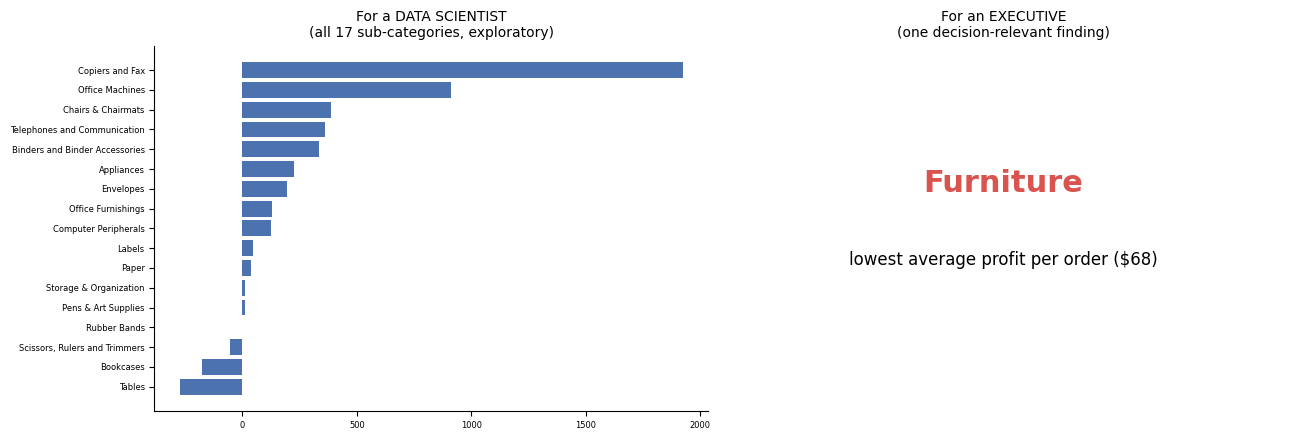

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Analyst view: dense, exploratory, every subcategory visible
sub_profit = sales.groupby("Product Sub-Category")["Profit"].mean().sort_values()
axes[0].barh(sub_profit.index, sub_profit.values, color="#4C72B0")
axes[0].tick_params(labelsize=6)
axes[0].set_title("For a DATA SCIENTIST\n(all 17 sub-categories, exploratory)", fontsize=10)

# Executive view: only the single decision-relevant fact
worst_cat = sales.groupby("Product Category")["Profit"].mean().idxmin()
worst_val = sales.groupby("Product Category")["Profit"].mean().min()
axes[1].axis("off")
axes[1].text(0.5, 0.6, worst_cat, ha="center", fontsize=22, fontweight="bold", color="#D9534F")
axes[1].text(0.5, 0.4, f"lowest average profit per order (${worst_val:.0f})", ha="center", fontsize=12)
axes[1].set_title("For an EXECUTIVE\n(one decision-relevant finding)", fontsize=10)

plt.tight_layout()
plt.show()

## 2. Designing for the Audience's Task & Directing Attention  *(Slides 6–7)*

**What:** The visualization should support the SPECIFIC task the audience needs to
perform (compare / identify a trend / find an exception / decide). A useful design
sequence: **establish context -> identify key info -> emphasize it -> de-emphasize
supporting elements.**

**Why:** Below, that exact 4-step sequence is applied to one chart, live.

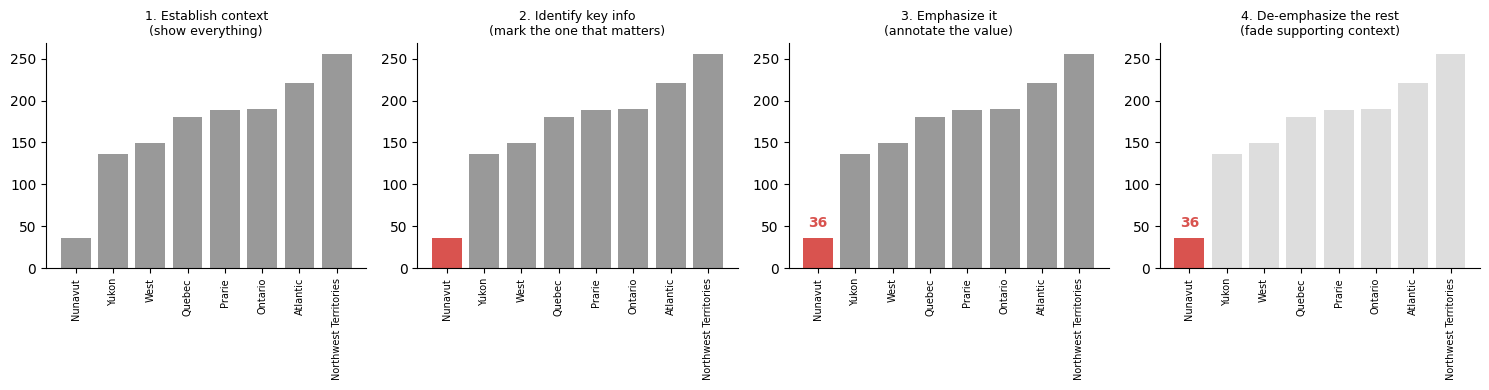

In [ ]:
region_profit = sales.groupby("Region")["Profit"].mean().sort_values()
worst_region = region_profit.idxmin()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].bar(region_profit.index, region_profit.values, color="#999999")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].set_title("1. Establish context\n(show everything)", fontsize=9)

colors_step2 = ["#D9534F" if r == worst_region else "#999999" for r in region_profit.index]
axes[1].bar(region_profit.index, region_profit.values, color=colors_step2)
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].set_title("2. Identify key info\n(mark the one that matters)", fontsize=9)

axes[2].bar(region_profit.index, region_profit.values, color=colors_step2)
axes[2].tick_params(axis="x", rotation=90, labelsize=7)
axes[2].annotate(f"{region_profit[worst_region]:.0f}", xy=(worst_region, region_profit[worst_region]),
                  xytext=(0, 8), textcoords="offset points", ha="center", fontweight="bold", color="#D9534F")
axes[2].set_title("3. Emphasize it\n(annotate the value)", fontsize=9)

colors_step4 = ["#D9534F" if r == worst_region else "#dddddd" for r in region_profit.index]
axes[3].bar(region_profit.index, region_profit.values, color=colors_step4)
axes[3].tick_params(axis="x", rotation=90, labelsize=7)
axes[3].annotate(f"{region_profit[worst_region]:.0f}", xy=(worst_region, region_profit[worst_region]),
                  xytext=(0, 8), textcoords="offset points", ha="center", fontweight="bold", color="#D9534F")
axes[3].set_title("4. De-emphasize the rest\n(fade supporting context)", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Strategic Highlighting  *(Slides 8–9)*

**What:** The full 5-step process: (1) establish context, (2) identify key information,
(3) de-emphasize supporting information, (4) highlight the important element using
accent color/contrast/bold/direct labeling, (5) check the overall hierarchy still reads
clearly as a whole.

**Why:** Below, all 5 steps are applied together to produce one final, board-ready
chart — the same underlying region-profit data as Section 2, now assembled into a single
finished figure.

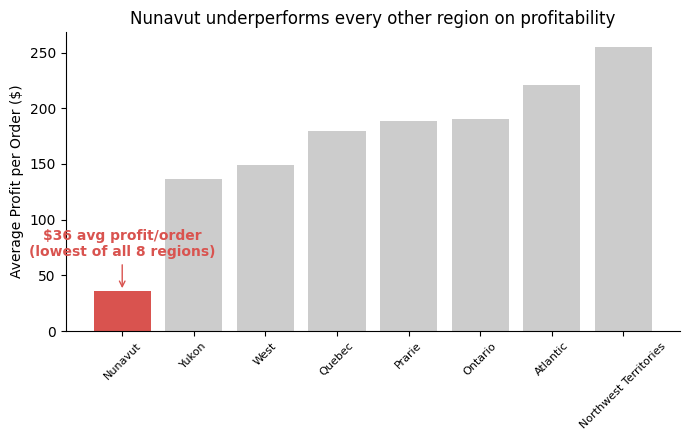

Step 5 check -- does the highlight still read clearly as part of the whole chart?
Yes: the gray bars still show the full context/range, so the red bar reads as
'the worst of 8', not as an isolated, context-free fact.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors_final = ["#D9534F" if r == worst_region else "#cccccc" for r in region_profit.index]
ax.bar(region_profit.index, region_profit.values, color=colors_final)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.annotate(f"${region_profit[worst_region]:.0f} avg profit/order\n(lowest of all 8 regions)",
            xy=(worst_region, region_profit[worst_region]), xytext=(0, 25), textcoords="offset points",
            ha="center", color="#D9534F", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#D9534F"))
ax.set_ylabel("Average Profit per Order ($)")
ax.set_title(f"{worst_region} underperforms every other region on profitability")
plt.tight_layout()
plt.show()

print("Step 5 check -- does the highlight still read clearly as part of the whole chart?")
print("Yes: the gray bars still show the full context/range, so the red bar reads as")
print("'the worst of 8', not as an isolated, context-free fact.")

## 4. Annotation as an Explanatory Layer & Designing Effective Annotations  *(Slides 10–11)*

**What:** Annotation forms include direct labels, callouts, reference lines,
explanatory notes, thresholds. Four design principles: (1) place annotations CLOSE to
their target, (2) use concise/specific language (not "interesting result"), (3)
establish a clear hierarchy between primary and supporting annotations, (4) avoid
annotation overload.

**Why:** Below, all four principles are demonstrated together on one chart.

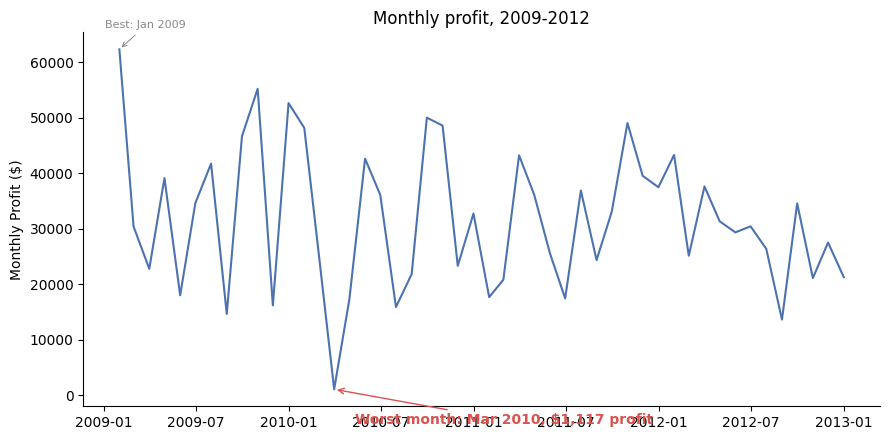

Notice what's absent: no callout on every one of the 48 months (Principle 4 --
avoiding annotation overload). Only the two points that matter most are labeled.


In [ ]:
monthly = sales.set_index("Order Date").resample("ME")["Profit"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, color="#4C72B0", lw=1.5)

worst_month = monthly.idxmin()
best_month = monthly.idxmax()

# Principle 1 & 2: close, specific annotation on the PRIMARY point
ax.annotate(f"Worst month: {worst_month:%b %Y}, ${monthly[worst_month]:,.0f} profit",
            xy=(worst_month, monthly[worst_month]), xytext=(15, -25), textcoords="offset points",
            fontsize=10, fontweight="bold", color="#D9534F",
            arrowprops=dict(arrowstyle="->", color="#D9534F"))

# Principle 3: a SECONDARY annotation, visually lighter than the primary one
ax.annotate(f"Best: {best_month:%b %Y}", xy=(best_month, monthly[best_month]), xytext=(-10, 15),
            textcoords="offset points", fontsize=8, color="#888888",
            arrowprops=dict(arrowstyle="->", color="#888888", lw=0.7))

ax.set_ylabel("Monthly Profit ($)")
ax.set_title("Monthly profit, 2009-2012")
plt.tight_layout()
plt.show()

print("Notice what's absent: no callout on every one of the 48 months (Principle 4 --")
print("avoiding annotation overload). Only the two points that matter most are labeled.")

## 5. Visual Design: Affordances and Hierarchy  *(Slides 12–13, 17–18)*

**What:** An **affordance** is a visual cue that signals how to read/interact with an
element (bold = important, muted = supporting, aligned = related). **Visual hierarchy**
uses size, weight, and color to establish primary -> secondary -> tertiary reading order
— the eye should land on the primary message FIRST, without instructions.

**Why:** Below, a single figure demonstrates all three hierarchy levels at once: the
headline number (primary), the supporting chart (secondary), and a footnote (tertiary).

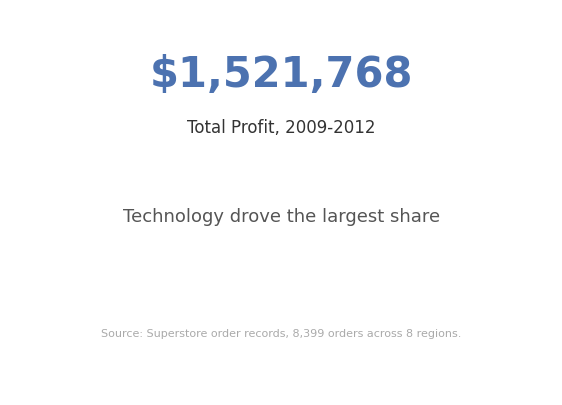

Font size + weight + color together create an unmistakable reading order --
no instructions needed for which line to read first.


In [ ]:
total_profit = sales.Profit.sum()
best_category = sales.groupby("Product Category").Profit.sum().idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Primary: largest, boldest, most colorful -- reads FIRST
ax.text(0.5, 0.8, f"${total_profit:,.0f}", ha="center", fontsize=30, fontweight="bold", color="#4C72B0")
ax.text(0.5, 0.68, "Total Profit, 2009-2012", ha="center", fontsize=12, color="#333333")

# Secondary: smaller, still colored, reads SECOND
ax.text(0.5, 0.45, f"Technology drove the largest share", ha="center", fontsize=13, color="#555555")

# Tertiary: smallest, gray, reads LAST (or not at all, and that's fine)
ax.text(0.5, 0.15, "Source: Superstore order records, 8,399 orders across 8 regions.",
        ha="center", fontsize=8, color="#aaaaaa")

plt.show()

print("Font size + weight + color together create an unmistakable reading order --")
print("no instructions needed for which line to read first.")

## 6. Alignment and Spatial Organization  *(Slide 19)*

**What:** Elements that are meant to be compared should be spatially aligned along a
shared axis/baseline. Misalignment forces the eye to do extra work reconciling
positions that should have been trivially comparable.

**Why:** Below, the same 3 category charts are shown misaligned (different baselines,
inconsistent sizing) vs. aligned (shared y-axis, consistent size) — try comparing bar
heights across panels in each version.

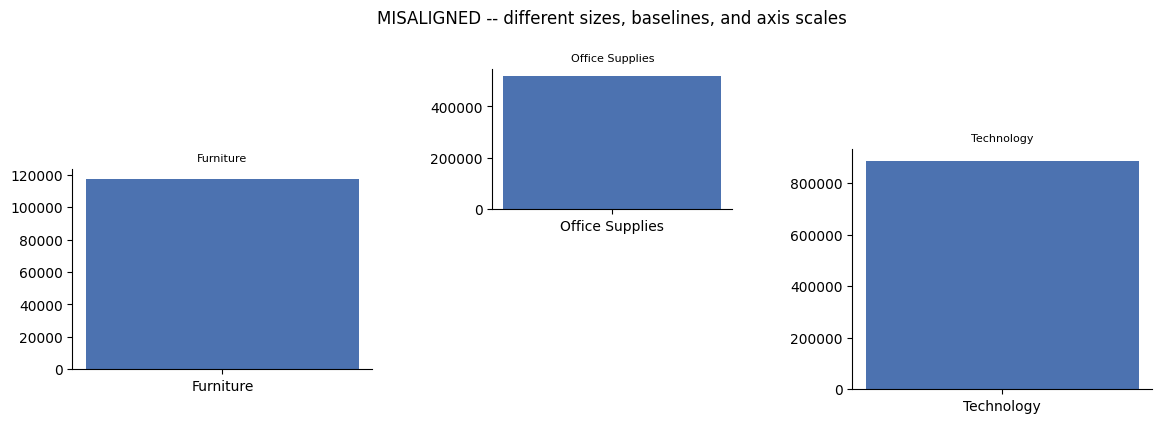

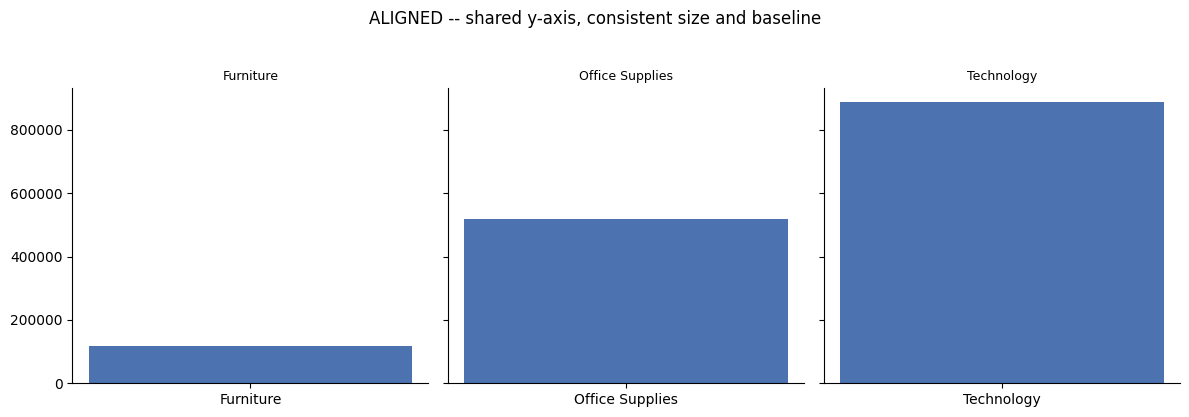

In [ ]:
cat_profit = sales.groupby("Product Category")["Profit"].sum()

fig = plt.figure(figsize=(12, 4))
# Misaligned: different sizes, different y-axis scales, inconsistent positions
sizes = [(0.05, 0.15, 0.25, 0.5), (0.4, 0.55, 0.2, 0.35), (0.7, 0.1, 0.25, 0.6)]
for i, (cat, (l, b, w, h)) in enumerate(zip(cat_profit.index, sizes)):
    ax = fig.add_axes([l, b, w, h])
    ax.bar([cat], [cat_profit[cat]], color="#4C72B0")
    ax.set_title(cat, fontsize=8)
plt.suptitle("MISALIGNED -- different sizes, baselines, and axis scales", y=1.05)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, cat in zip(axes, cat_profit.index):
    ax.bar([cat], [cat_profit[cat]], color="#4C72B0")
    ax.set_title(cat, fontsize=9)
plt.suptitle("ALIGNED -- shared y-axis, consistent size and baseline", y=1.03)
plt.tight_layout()
plt.show()

## 7. Proximity and Whitespace  *(Slides 20–21)*

**What:** Related elements should sit close together; unrelated elements need enough
whitespace to read as separate groups (Gestalt proximity, revisited from PPT5 in a
design context). Whitespace is not "wasted space" — it's what lets the eye segment a
dense layout into digestible chunks.

**Why:** Below, three summary metrics are packed with zero spacing vs. given
deliberate whitespace between cards.

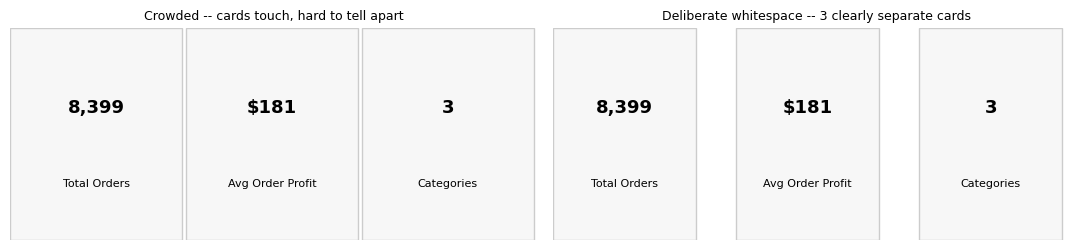

In [ ]:
metrics = [("Total Orders", f"{len(sales):,}"), ("Avg Order Profit", f"${sales.Profit.mean():.0f}"),
           ("Categories", f"{sales['Product Category'].nunique()}")]

fig, axes = plt.subplots(1, 2, figsize=(11, 2.6))

# Crowded: zero gap between cards
axes[0].axis("off")
for i, (label, val) in enumerate(metrics):
    x0 = i * 1.0  # no gap
    axes[0].add_patch(mpatches.Rectangle((x0, 0), 0.98, 1, edgecolor="#cccccc", facecolor="#f7f7f7"))
    axes[0].text(x0 + 0.49, 0.6, val, ha="center", fontsize=13, fontweight="bold")
    axes[0].text(x0 + 0.49, 0.25, label, ha="center", fontsize=8)
axes[0].set_xlim(0, 3); axes[0].set_ylim(0, 1)
axes[0].set_title("Crowded -- cards touch, hard to tell apart", fontsize=9)

# Spaced: deliberate whitespace between cards
axes[1].axis("off")
for i, (label, val) in enumerate(metrics):
    x0 = i * 1.25
    axes[1].add_patch(mpatches.Rectangle((x0, 0), 0.98, 1, edgecolor="#cccccc", facecolor="#f7f7f7"))
    axes[1].text(x0 + 0.49, 0.6, val, ha="center", fontsize=13, fontweight="bold")
    axes[1].text(x0 + 0.49, 0.25, label, ha="center", fontsize=8)
axes[1].set_xlim(0, 3.6); axes[1].set_ylim(0, 1)
axes[1].set_title("Deliberate whitespace -- 3 clearly separate cards", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Words as Part of the Visualization  *(Slide 22)*

**What:** Titles, axis labels, and legends are part of the visualization's design, not
an afterthought. A generic title wastes the most valuable text real estate in the
figure — the one line guaranteed to be read.

**Why:** Below, a generic chart title vs. a descriptive, conclusion-bearing title, on
the same chart.

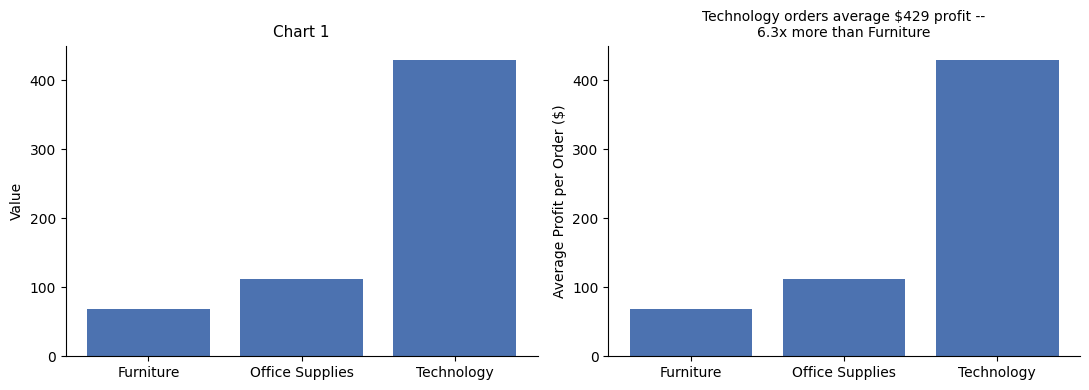

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = sales.groupby("Product Category")["Profit"].mean().sort_values()

axes[0].bar(order.index, order.values, color="#4C72B0")
axes[0].set_title("Chart 1", fontsize=11)   # generic, uninformative
axes[0].set_ylabel("Value")

axes[1].bar(order.index, order.values, color="#4C72B0")
axes[1].set_title(f"Technology orders average ${order.max():.0f} profit --\n"
                   f"{order.max()/order.min():.1f}x more than Furniture", fontsize=10)
axes[1].set_ylabel("Average Profit per Order ($)")

plt.tight_layout()
plt.show()

## 9. Data Labels: When and Where to Use Them  *(Slide 23)*

**What:** Data labels add precision but also visual weight. Label EVERY point only when
precision matters more than clarity (e.g. a small table-like chart); for larger charts,
label only the exceptions/extremes and let position/length carry the rest.

**Why:** Below, labeling all 17 sub-categories (cluttered) vs. labeling only the two
extremes (clean, still precise where it matters).

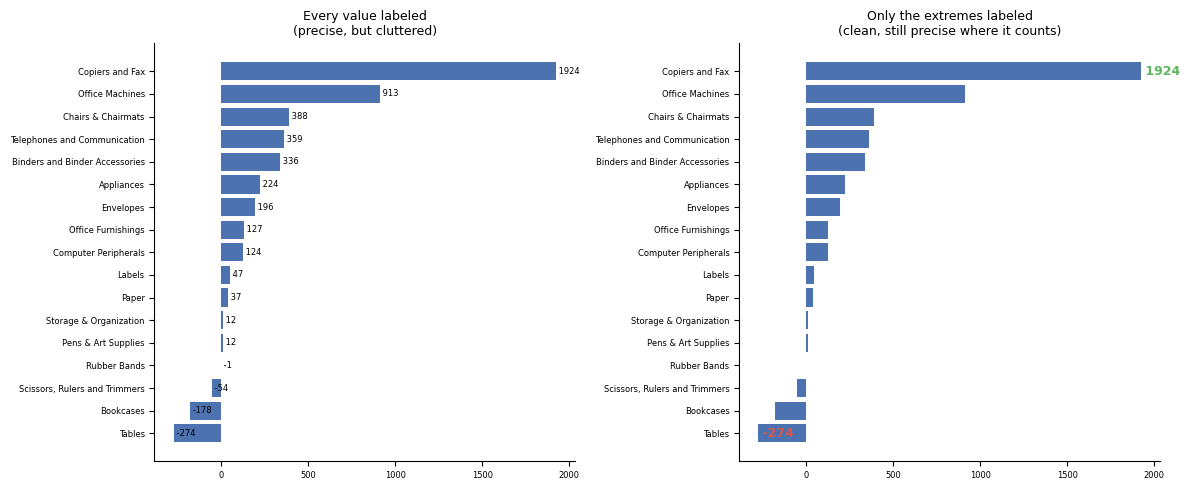

In [ ]:
sub_profit = sales.groupby("Product Sub-Category")["Profit"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(sub_profit.index, sub_profit.values, color="#4C72B0")
for i, v in enumerate(sub_profit.values):
    axes[0].text(v, i, f" {v:.0f}", va="center", fontsize=6)
axes[0].tick_params(labelsize=6)
axes[0].set_title("Every value labeled\n(precise, but cluttered)", fontsize=9)

axes[1].barh(sub_profit.index, sub_profit.values, color="#4C72B0")
axes[1].tick_params(labelsize=6)
worst_sub, best_sub = sub_profit.index[0], sub_profit.index[-1]
axes[1].text(sub_profit[worst_sub], 0, f" {sub_profit[worst_sub]:.0f}", va="center", fontsize=9, fontweight="bold", color="#D9534F")
axes[1].text(sub_profit[best_sub], len(sub_profit)-1, f" {sub_profit[best_sub]:.0f}", va="center", fontsize=9, fontweight="bold", color="#5cb85c")
axes[1].set_title("Only the extremes labeled\n(clean, still precise where it counts)", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Annotation: Identification vs. Interpretation & Structured Layer  *(Slides 24–25)*

**What:**
- **Identification annotation** names WHAT a point is ("Tables sub-category").
- **Interpretation annotation** explains WHY it matters ("consistently loses money —
  investigate pricing").
- Every annotation has 3 structural parts: **Target** (what it points to), **Connector**
  (the leader line), **Message** (the text).

**Why:** Below, both annotation types are shown on the same chart, with their
Target/Connector/Message parts labeled explicitly.

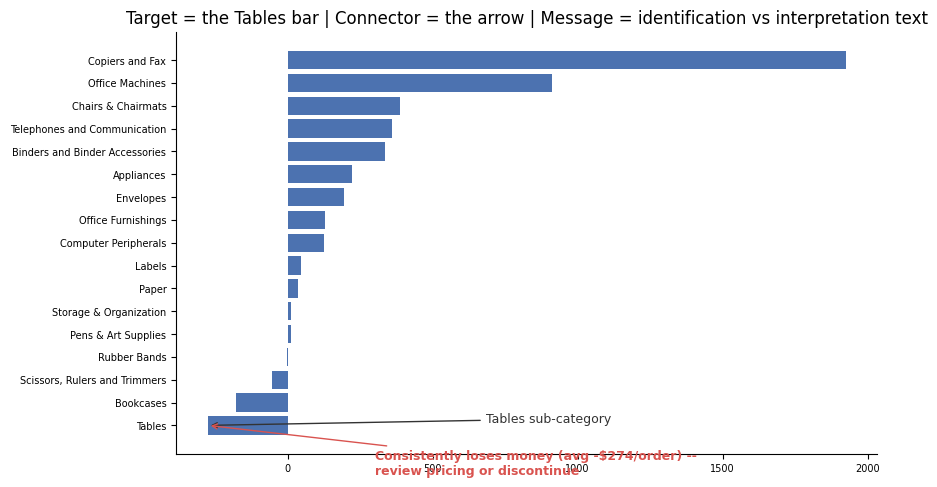

In [ ]:
sub_profit_full = sales.groupby("Product Sub-Category")["Profit"].mean().sort_values()
worst_sub = sub_profit_full.index[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sub_profit_full.index, sub_profit_full.values, color="#4C72B0")
ax.tick_params(labelsize=7)

# Identification: just names the target
ax.annotate("Tables sub-category", xy=(sub_profit_full[worst_sub], 0), xytext=(200, 2),
            textcoords="offset points", fontsize=9, color="#333333",
            arrowprops=dict(arrowstyle="->", color="#333333"))

# Interpretation: explains WHY it matters (further down, offset to avoid overlap)
ax.annotate(f"Consistently loses money (avg -${abs(sub_profit_full[worst_sub]):.0f}/order) --\nreview pricing or discontinue",
            xy=(sub_profit_full[worst_sub], 0), xytext=(120, -35),
            textcoords="offset points", fontsize=9, color="#D9534F", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#D9534F"))

ax.set_title("Target = the Tables bar | Connector = the arrow | Message = identification vs interpretation text")
plt.tight_layout()
plt.show()

## 11. Annotation Placement & Density/Clutter  *(Slides 26–27)*

**What:** Placement: close annotations (near the target) are read fastest; distant
annotations need a clear connector line, or the eye loses the link. Density: too few
annotations under-explain; too many bury the signal in noise — there's a legible middle
ground.

**Why:** Below, three densities of the same chart: no annotation, well-annotated, and
over-annotated.

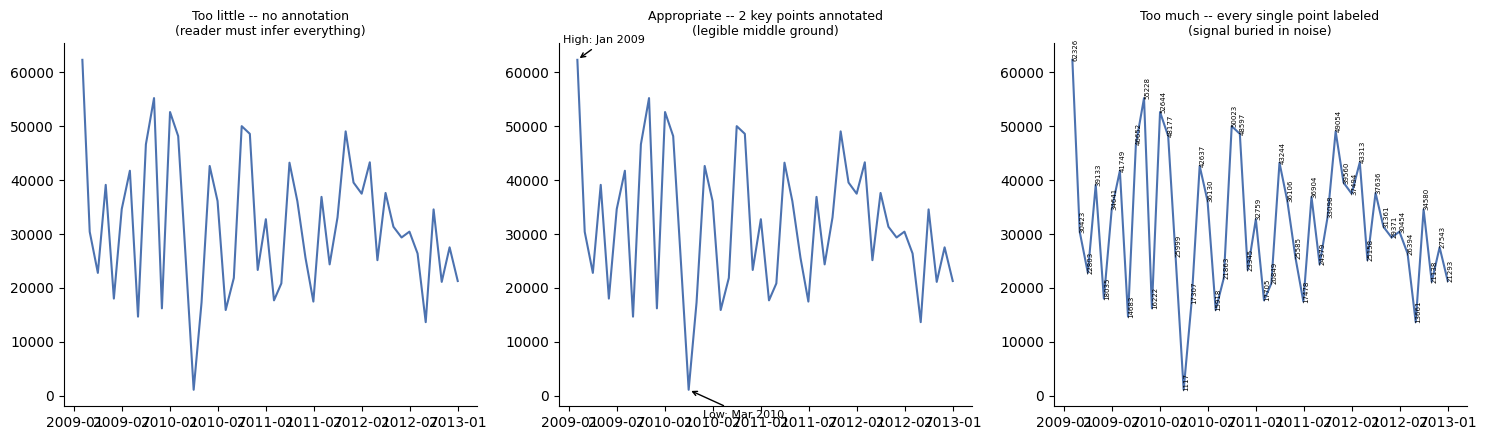

In [ ]:
monthly = sales.set_index("Order Date").resample("ME")["Profit"].sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(monthly.index, monthly.values, color="#4C72B0")
axes[0].set_title("Too little -- no annotation\n(reader must infer everything)", fontsize=9)

axes[1].plot(monthly.index, monthly.values, color="#4C72B0")
worst_month, best_month = monthly.idxmin(), monthly.idxmax()
axes[1].annotate(f"Low: {worst_month:%b %Y}", xy=(worst_month, monthly[worst_month]), xytext=(10, -20),
                  textcoords="offset points", fontsize=8, arrowprops=dict(arrowstyle="->"))
axes[1].annotate(f"High: {best_month:%b %Y}", xy=(best_month, monthly[best_month]), xytext=(-10, 12),
                  textcoords="offset points", fontsize=8, arrowprops=dict(arrowstyle="->"))
axes[1].set_title("Appropriate -- 2 key points annotated\n(legible middle ground)", fontsize=9)

axes[2].plot(monthly.index, monthly.values, color="#4C72B0")
for i, (date, val) in enumerate(monthly.items()):
    axes[2].annotate(f"{val:.0f}", xy=(date, val), fontsize=5, rotation=90)
axes[2].set_title("Too much -- every single point labeled\n(signal buried in noise)", fontsize=9)

plt.tight_layout()
plt.show()

## 12. Accessibility in Data Visualization  *(Slides 14–16, 28)*

**What:** Accessibility means the visualization remains usable for viewers with color
vision deficiency, low vision, or unfamiliarity with domain jargon. Practical fixes:
avoid color-only encoding (add redundant shape/pattern), avoid unexplained
abbreviations, ensure sufficient contrast, provide clear labels.

**Why:** Below, our category-profit chart is shown with color-only encoding (breaks
under colorblind simulation) vs. redundant color+pattern encoding (survives it).

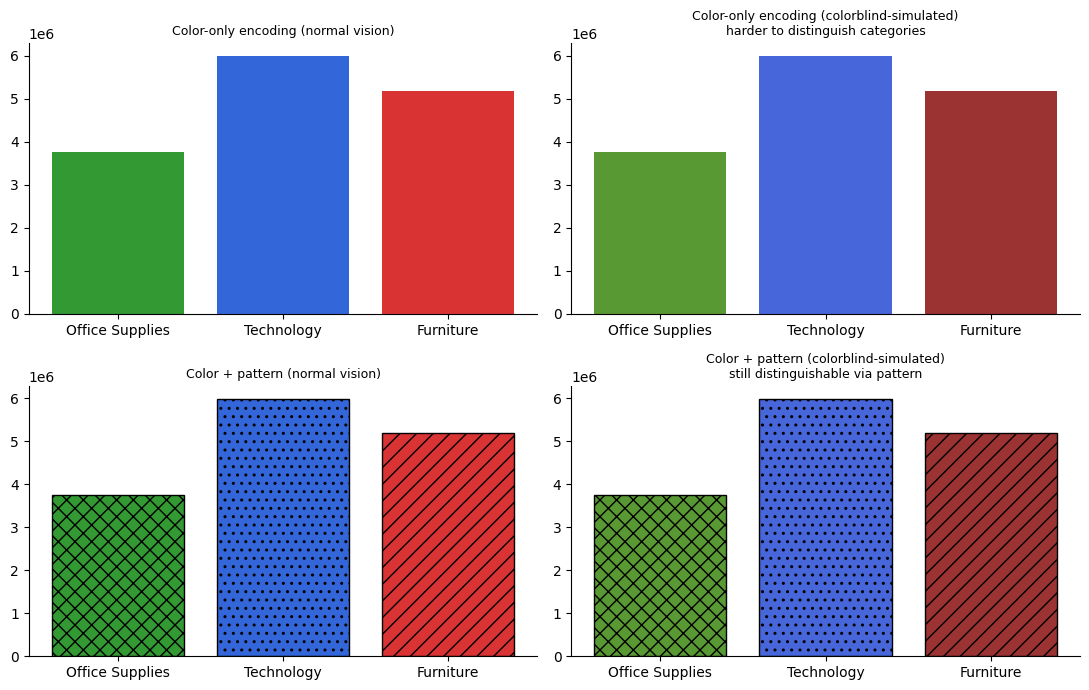

In [ ]:
def simulate_deuteranopia(rgb):
    # A simple approximation of red-green colorblindness for illustration
    r, g, b = rgb[:3]
    return (0.625*r + 0.375*g, 0.7*g + 0.3*g, b)

cats = sales["Product Category"].unique()
cat_colors = {"Furniture": (0.85, 0.2, 0.2), "Office Supplies": (0.2, 0.6, 0.2), "Technology": (0.2, 0.4, 0.85)}
cat_values = sales.groupby("Product Category")["Sales"].sum()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Color-only, normal vision
for cat in cats:
    axes[0,0].bar(cat, cat_values[cat], color=cat_colors[cat])
axes[0,0].set_title("Color-only encoding (normal vision)", fontsize=9)

# Color-only, simulated colorblind vision
for cat in cats:
    axes[0,1].bar(cat, cat_values[cat], color=simulate_deuteranopia(cat_colors[cat]))
axes[0,1].set_title("Color-only encoding (colorblind-simulated)\nharder to distinguish categories", fontsize=9)

# Redundant color+pattern, normal vision
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}
for cat in cats:
    axes[1,0].bar(cat, cat_values[cat], color=cat_colors[cat], hatch=hatches[cat], edgecolor="black")
axes[1,0].set_title("Color + pattern (normal vision)", fontsize=9)

# Redundant color+pattern, simulated colorblind vision
for cat in cats:
    axes[1,1].bar(cat, cat_values[cat], color=simulate_deuteranopia(cat_colors[cat]), hatch=hatches[cat], edgecolor="black")
axes[1,1].set_title("Color + pattern (colorblind-simulated)\nstill distinguishable via pattern", fontsize=9)

plt.tight_layout()
plt.show()

## 13. Integral vs. Separable Visual Dimensions  *(Slide 29)*

**What:** Recap from PPT4's saliency material, applied to design choice: **integral**
dimensions (e.g. an ellipse's width+height) are perceived holistically as one shape;
**separable** dimensions (e.g. a circle's color+size) can be judged independently.
Design implication: use SEPARABLE channels when a viewer needs to compare attributes
independently.

**Why:** Below, region profit (color) and order count (size) are encoded on separable
circle dimensions — a viewer can judge "which is more profitable" and "which has more
orders" independently, without one channel distorting the other.

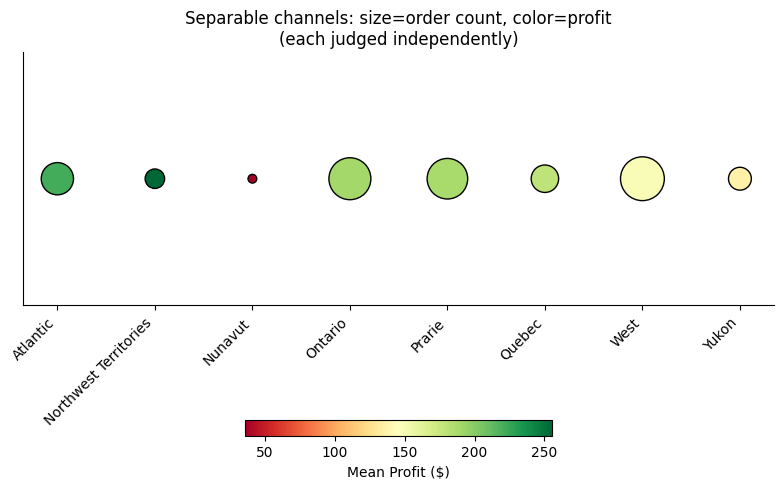

In [ ]:
region_summary = sales.groupby("Region").agg(mean_profit=("Profit", "mean"), n=("Profit", "size")).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(range(len(region_summary)), [0]*len(region_summary), s=region_summary.n/2,
                 c=region_summary.mean_profit, cmap="RdYlGn", edgecolor="black")
ax.set_xticks(range(len(region_summary)))
ax.set_xticklabels(region_summary.Region, rotation=45, ha="right")
ax.set_yticks([])
plt.colorbar(sc, ax=ax, label="Mean Profit ($)", orientation="horizontal", pad=0.3, fraction=0.04)
ax.set_title("Separable channels: size=order count, color=profit\n(each judged independently)")
plt.tight_layout()
plt.show()

## 14. Luminance Contrast — Worked Example  *(Slides 30–31)*

**What:** Relative luminance contrast between text/marks and their background
determines legibility. A common simplified formula: `contrast = |L1 - L2| / max(L1, L2)`
where L1, L2 are luminance values on a 0–100 scale. Reproducing the lecture's own worked
example: L1 = 80, L2 = 20.

In [ ]:
L1, L2 = 80, 20
contrast = abs(L1 - L2) / max(L1, L2)
print(f"L1 = {L1}, L2 = {L2}")
print(f"Contrast = |L1 - L2| / max(L1, L2) = |{L1}-{L2}| / {max(L1,L2)} = {contrast:.2f}  ({contrast*100:.0f}%)")
print("A well-designed accessible palette should keep this ratio comfortably high for any text/mark that must be read.")

L1 = 80, L2 = 20
Contrast = |L1 - L2| / max(L1, L2) = |80-20| / 80 = 0.75  (75%)
A well-designed accessible palette should keep this ratio comfortably high for any text/mark that must be read.


In [ ]:
# Applied check: is our red highlight (Section 3) readable against a white figure background?
def relative_luminance_srgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(c):
        return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
    r, g, b = lin(r), lin(g), lin(b)
    return (0.2126*r + 0.7152*g + 0.0722*b) * 100

L_red = relative_luminance_srgb("#D9534F")
L_white = relative_luminance_srgb("#FFFFFF")
contrast_applied = abs(L_red - L_white) / max(L_red, L_white)
print(f"Our highlight red (#D9534F) vs white background: luminance contrast = {contrast_applied:.2f} ({contrast_applied*100:.0f}%)")
print("A high contrast ratio here is exactly why the red highlight bars in Sections 2-3 stayed legible.")

Our highlight red (#D9534F) vs white background: luminance contrast = 0.78 (78%)
A high contrast ratio here is exactly why the red highlight bars in Sections 2-3 stayed legible.


## 15. Quantitative Limits of Grayscale  *(Slide 32)*

**What:** Viewers reading a grayscale-encoded quantity (printed reports, grayscale
displays) make noticeably larger estimation errors than with a well-designed color
scale — research cited in the lecture suggests roughly 20%+ higher error for fine
quantity discrimination in grayscale.

**Why:** Below, the same 6 profit values are shown as grayscale swatches vs. a
sequential color scale — try ranking the swatches by value in each row.

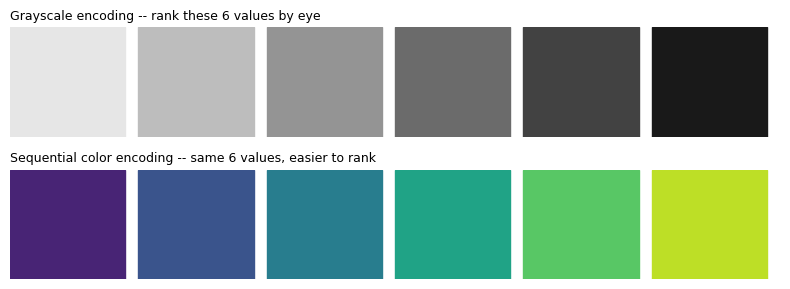

Research cited in the lecture: grayscale-only quantity discrimination produces roughly
20%+ higher estimation error than a well-designed sequential color scale.


In [ ]:
vals = np.linspace(0.1, 0.9, 6)

fig, axes = plt.subplots(2, 1, figsize=(8, 3))
for i, v in enumerate(vals):
    axes[0].add_patch(mpatches.Rectangle((i, 0), 0.9, 1, color=str(1-v)))
axes[0].set_xlim(0, 6); axes[0].set_ylim(0, 1); axes[0].axis("off")
axes[0].set_title("Grayscale encoding -- rank these 6 values by eye", fontsize=9, loc="left")

for i, v in enumerate(vals):
    axes[1].add_patch(mpatches.Rectangle((i, 0), 0.9, 1, color=plt.cm.viridis(v)))
axes[1].set_xlim(0, 6); axes[1].set_ylim(0, 1); axes[1].axis("off")
axes[1].set_title("Sequential color encoding -- same 6 values, easier to rank", fontsize=9, loc="left")

plt.tight_layout()
plt.show()

print("Research cited in the lecture: grayscale-only quantity discrimination produces roughly")
print("20%+ higher estimation error than a well-designed sequential color scale.")

## 16. Accessibility: A Practical Design Check  *(Slide 33)*

| Check | Question |
|---|---|
| Color-blind safe? | Does the message survive if color is removed entirely? |
| Sufficient contrast? | Is every mark/text legible against its background? |
| Grayscale-safe? | Does it still work if printed in black and white? |
| No unexplained jargon? | Are abbreviations/domain terms defined? |
| Clear labels? | Are axes, legends, and units all present and legible? |

## 17. Accuracy vs. Interpretation  *(Slides 34–35)*

**What:** The SAME two real, close values can be drawn to look nearly identical (honest)
or dramatically different (exaggerated), purely through axis and framing choices,
without any number being falsified.

**Why:** Below, 2010 vs. 2011 total sales — a real ~3.2% year-over-year difference —
shown first honestly (zero baseline), then with an exaggerated framing (truncated axis
+ 3D-style bevel) that makes a modest real difference look dramatic.

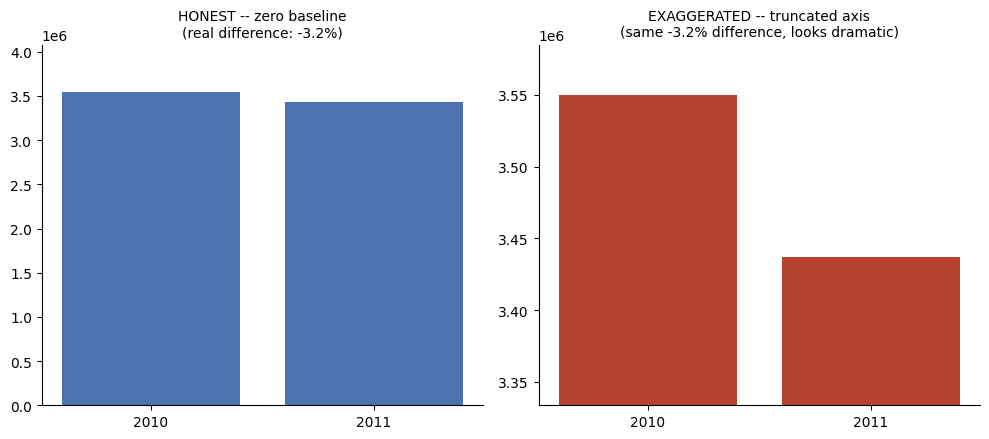

2010 sales: $3,549,681  |  2011 sales: $3,436,817  |  real change: -3.2%
Neither chart shows a false number -- but only one accurately communicates HOW LARGE the change is.


In [ ]:
yearly_sales = sales.groupby("Year")["Sales"].sum()
y1, y2 = 2010, 2011
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct_diff = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_title(f"HONEST -- zero baseline\n(real difference: {pct_diff:.1f}%)", fontsize=10)

axes[1].bar([str(y1), str(y2)], [v1, v2], color="#b5432e")
axes[1].set_ylim(min(v1, v2) * 0.97, max(v1, v2) * 1.01)
axes[1].set_title(f"EXAGGERATED -- truncated axis\n(same {pct_diff:.1f}% difference, looks dramatic)", fontsize=10)

plt.tight_layout()
plt.show()

print(f"{y1} sales: ${v1:,.0f}  |  {y2} sales: ${v2:,.0f}  |  real change: {pct_diff:+.1f}%")
print("Neither chart shows a false number -- but only one accurately communicates HOW LARGE the change is.")

## 18. The Visualization as a Transformation  *(Slide 36)*

**What:** Every chart is the output of a pipeline: **raw data -> filtering ->
aggregation -> encoding -> chart**. Each step is a DECISION, and each decision can
change the story — the "chart" is never a neutral window onto the raw data.

**Why:** Below, the exact same `sales` table is walked through this pipeline explicitly,
showing how each step transforms 8,399 raw rows into one number.

RAW DATA: 8,399 individual order rows
FILTER (Technology only): 2,065 rows remain


AGGREGATE (sum by year): 4 numbers remain
Year
2009    194645.22
2010    237422.72
2011    243634.53
2012    210611.05
Name: Profit, dtype: float64

ENCODE: each of those 4 numbers becomes one bar's height in the final chart.


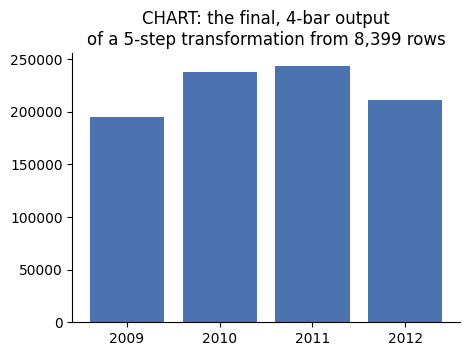

In [ ]:
print(f"RAW DATA: {len(sales):,} individual order rows")

filtered = sales[sales["Product Category"] == "Technology"]
print(f"FILTER (Technology only): {len(filtered):,} rows remain")

aggregated = filtered.groupby("Year")["Profit"].sum()
print(f"AGGREGATE (sum by year): {len(aggregated)} numbers remain\n{aggregated}")

print(f"\nENCODE: each of those {len(aggregated)} numbers becomes one bar's height in the final chart.")
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(aggregated.index.astype(str), aggregated.values, color="#4C72B0")
ax.set_title("CHART: the final, 4-bar output\nof a 5-step transformation from 8,399 rows")
plt.show()

## 19. Uncertainty Is Information & Can Change the Decision  *(Slides 37–38)*

**What:** A point estimate hides how confident we should be. Showing uncertainty isn't
just "more honest" — it can change what a viewer should actually DECIDE. Two regions
whose confidence intervals OVERLAP should not be read as "clearly different," even if
their point estimates differ.

**Why:** Below, two adjacent-ranked regions' average profit is shown as bare points
(implying region B is clearly better) and then with bootstrap 95% CIs (revealing they
actually overlap).

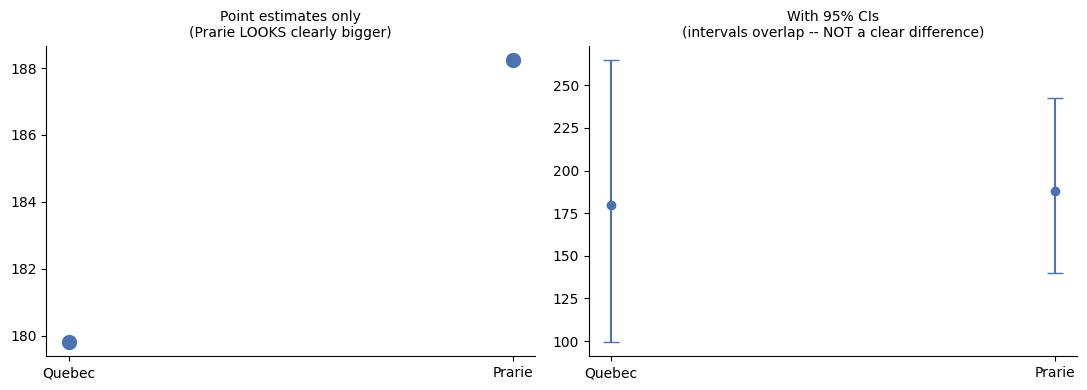

Quebec: 179.8  95% CI [99.4, 265.1]
Prarie: 188.3  95% CI [139.8, 242.5]

Overlap: YES -- the point-estimate-only chart overstated confidence


In [ ]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return np.mean(values), np.percentile(means, 2.5), np.percentile(means, 97.5)

region_means = sales.groupby("Region")["Profit"].mean().sort_values()
region_a, region_b = region_means.index[3], region_means.index[4]  # two adjacent-ranked regions

vals_a = sales[sales.Region == region_a].Profit.values
vals_b = sales[sales.Region == region_b].Profit.values
mean_a, lo_a, hi_a = bootstrap_ci(vals_a)
mean_b, lo_b, hi_b = bootstrap_ci(vals_b)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter([region_a, region_b], [mean_a, mean_b], s=100, color="#4C72B0")
axes[0].set_title(f"Point estimates only\n({region_b} LOOKS clearly bigger)", fontsize=10)

axes[1].errorbar([region_a, region_b], [mean_a, mean_b], yerr=[[mean_a-lo_a, mean_b-lo_b], [hi_a-mean_a, hi_b-mean_b]],
                  fmt="o", capsize=6, color="#4C72B0")
axes[1].set_title(f"With 95% CIs\n(intervals overlap -- NOT a clear difference)", fontsize=10)

plt.tight_layout()
plt.show()

print(f"{region_a}: {mean_a:.1f}  95% CI [{lo_a:.1f}, {hi_a:.1f}]")
print(f"{region_b}: {mean_b:.1f}  95% CI [{lo_b:.1f}, {hi_b:.1f}]")
print(f"\nOverlap: {'YES -- the point-estimate-only chart overstated confidence' if hi_a > lo_b else 'no overlap'}")

## 20. Scale Is a Communication Decision  *(Slide 39)*

**What:** Choosing linear vs. log scale, and choosing axis bounds, are not neutral
technical defaults — they are communication decisions that change how large a real
difference appears to be.

**Why:** Below, the real ~8.2% year-over-year sales increase (2011 -> 2012) is shown on
a wide axis (looks modest) and a narrow axis (looks dramatic) — same 8.2%, two very
different visual impressions.

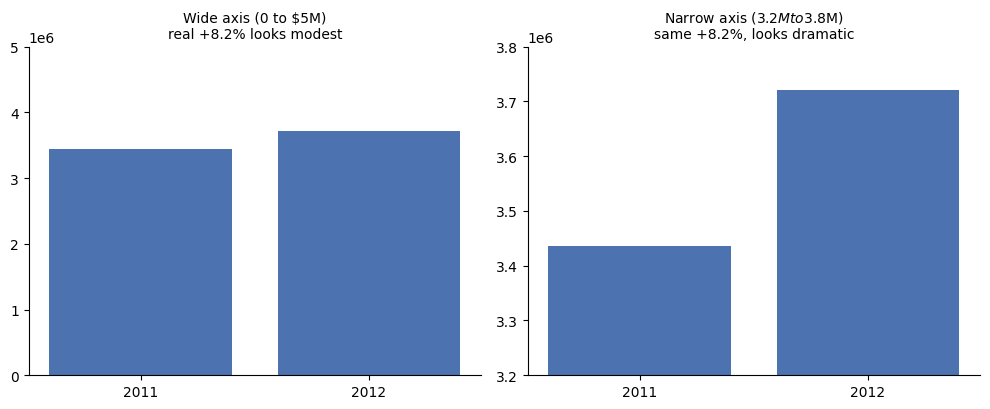

Neither axis is 'illegal' -- but each is a DECISION about how large the story should look.
The ethical requirement is to pick deliberately and disclose the choice, not default blindly.


In [ ]:
y1, y2 = 2011, 2012
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, 5e6)
axes[0].set_title(f"Wide axis (0 to $5M)\nreal +{pct:.1f}% looks modest", fontsize=10)

axes[1].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[1].set_ylim(3.2e6, 3.8e6)
axes[1].set_title(f"Narrow axis ($3.2M to $3.8M)\nsame +{pct:.1f}%, looks dramatic", fontsize=10)

plt.tight_layout()
plt.show()

print("Neither axis is 'illegal' -- but each is a DECISION about how large the story should look.")
print("The ethical requirement is to pick deliberately and disclose the choice, not default blindly.")

## 21. Aggregation Can Hide Structure  *(Slide 40)*

**What:** Two groups can share nearly the same MEAN while having completely different
underlying distributions (shape, spread, modality). A single summary statistic can
erase exactly the structure that matters most.

**Why:** Below, two real sub-categories with almost identical average profit —
`Pens & Art Supplies` and `Storage & Organization` — but wildly different spread. A
bar chart of means alone would make them look like the same story.

                             mean         std  count
Product Sub-Category                                
Pens & Art Supplies     11.950679   77.341605    633
Storage & Organization  12.205403  848.234047    546


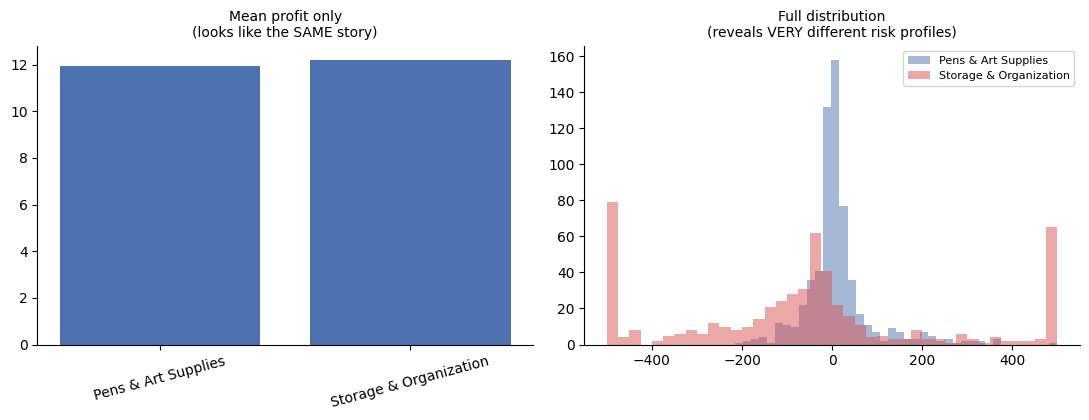

Nearly identical means (12.0 vs 12.2), but standard
deviations of 77 vs 848 -- one is a low-risk steady
seller, the other swings between big wins and big losses. The mean alone hides this entirely.


In [ ]:
sub_stats = sales.groupby("Product Sub-Category")["Profit"].agg(["mean", "std", "count"])
pair = sub_stats.loc[["Pens & Art Supplies", "Storage & Organization"]]
print(pair)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].bar(pair.index, pair["mean"], color="#4C72B0")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_title("Mean profit only\n(looks like the SAME story)", fontsize=10)

for cat, color in zip(pair.index, ["#4C72B0", "#D9534F"]):
    vals = sales[sales["Product Sub-Category"] == cat].Profit.clip(-500, 500)
    axes[1].hist(vals, bins=40, alpha=0.5, label=cat, color=color)
axes[1].legend(fontsize=8)
axes[1].set_title("Full distribution\n(reveals VERY different risk profiles)", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Nearly identical means ({pair['mean'].iloc[0]:.1f} vs {pair['mean'].iloc[1]:.1f}), but standard")
print(f"deviations of {pair['std'].iloc[0]:.0f} vs {pair['std'].iloc[1]:.0f} -- one is a low-risk steady")
print("seller, the other swings between big wins and big losses. The mean alone hides this entirely.")

## 22. Selection and Omission  *(Slide 41)*

**What:** Choosing WHERE a time series starts can completely change its apparent story
— even with zero numbers changed. This is the lecture's own example (does the chart
start in 2018 or 2021?), reproduced with our real 2009–2012 data.

**Why:** Below: the full 2009–2012 trend (reveals a 2009 peak, a crash, then partial
recovery) vs. a chart that starts at 2011 (looks like uninterrupted growth).

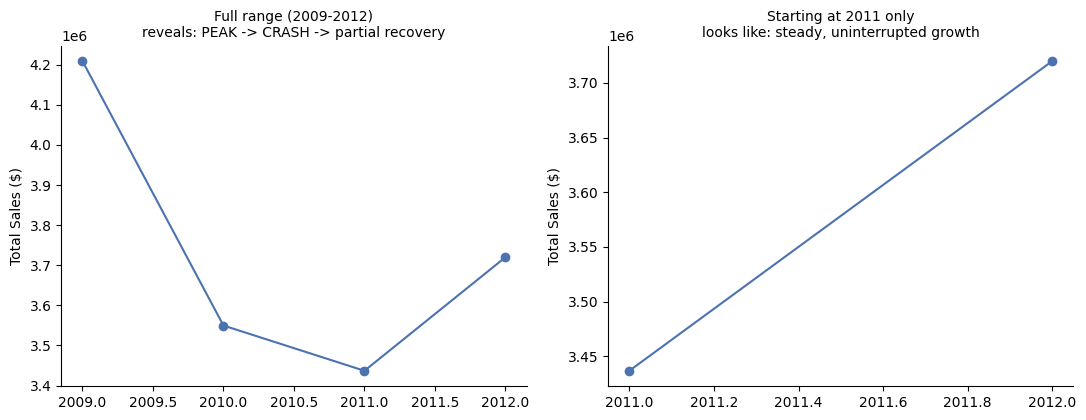

Both charts use 100%% real, unaltered numbers. Only the SELECTED WINDOW changed --
and that alone flips the story from 'still recovering from a crash' to 'steady growth.'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
axes[0].set_title("Full range (2009-2012)\nreveals: PEAK -> CRASH -> partial recovery", fontsize=10)
axes[0].set_ylabel("Total Sales ($)")

recent = yearly_sales.loc[2011:]
axes[1].plot(recent.index, recent.values, "o-", color="#4C72B0")
axes[1].set_title("Starting at 2011 only\nlooks like: steady, uninterrupted growth", fontsize=10)
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

print("Both charts use 100%% real, unaltered numbers. Only the SELECTED WINDOW changed --")
print("and that alone flips the story from 'still recovering from a crash' to 'steady growth.'")

## 23. Annotation Is Also Rhetoric  *(Slide 42)*

**What:** The SAME chart, with the SAME numbers, can carry three very different
rhetorical stances depending purely on annotation wording: descriptive (states the
fact), interpretive (explains a plausible cause), or persuasive (pushes toward a
specific action/conclusion, sometimes overreaching what the data actually supports).

**Why:** Below, one chart, three annotation styles.

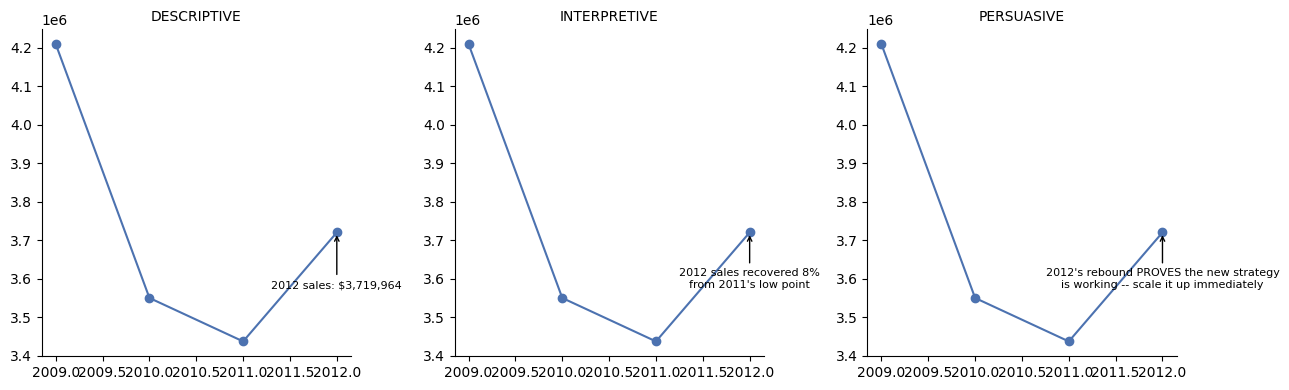

All three annotations describe the SAME data point. Only the DESCRIPTIVE one makes no
claim beyond the number itself; the PERSUASIVE one asserts causation the data alone cannot support.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, style, text in zip(
    axes, ["DESCRIPTIVE", "INTERPRETIVE", "PERSUASIVE"],
    [f"2012 sales: ${yearly_sales[2012]:,.0f}",
     f"2012 sales recovered {((yearly_sales[2012]-yearly_sales[2011])/yearly_sales[2011]*100):.0f}%\nfrom 2011's low point",
     f"2012's rebound PROVES the new strategy\nis working -- scale it up immediately"]
):
    ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
    ax.annotate(text, xy=(2012, yearly_sales[2012]), xytext=(0, -40), textcoords="offset points",
                ha="center", fontsize=8, arrowprops=dict(arrowstyle="->"))
    ax.set_title(style, fontsize=10)
plt.tight_layout()
plt.show()

print("All three annotations describe the SAME data point. Only the DESCRIPTIVE one makes no")
print("claim beyond the number itself; the PERSUASIVE one asserts causation the data alone cannot support.")

## 24. Visual Rhetoric: Where Bias Enters  *(Slides 43–44)*

| Pipeline stage | Where bias can enter |
|---|---|
| Data collection | What was measured, what wasn't |
| Filtering | Which subset is shown vs. hidden |
| Aggregation | Which summary statistic is chosen (mean vs. median vs. total) |
| Encoding | Axis scale, color scale, chart type |
| Annotation | Descriptive vs. interpretive vs. persuasive language |
| Layout/emphasis | What's highlighted vs. de-emphasized |

Every one of Sections 17–23 above demonstrated bias entering at exactly one of these
stages — using the SAME real dataset each time.

## 25. The Ethical Visualization Audit  *(Slide 45)*

Before publishing any chart, ask:
1. Does the axis/scale choice honestly represent the magnitude of the difference?
2. Is uncertainty shown wherever a value is an estimate?
3. Does the selected time window/subset represent the full available picture?
4. Does annotation language match what the data can actually support (no overreach)?
5. Would this chart still make its point if redrawn with the opposite framing choices?

**Applying it to one of our own charts** — Section 20's "narrow axis" panel:

In [ ]:
audit = {
    "1. Honest scale?": "NO -- the narrow-axis version in Section 20 exaggerates a real 8.2% change.",
    "2. Uncertainty shown?": "NO -- Section 20 shows bare point estimates, no confidence interval.",
    "3. Full picture shown?": "NO -- Section 22 shows how starting at 2011 hides the 2009 peak/crash.",
    "4. Annotation matches evidence?": "Depends -- Section 23's persuasive version overreaches into causal claims.",
    "5. Survives opposite framing?": "NO -- Section 20's story flips entirely if the wide-axis version were used instead.",
}
for q, a in audit.items():
    print(f"{q}\n  {a}\n")

print("This audit is exactly why Section 20's wide-axis (zero-baseline) version, paired with")
print("Section 19's uncertainty band and Section 22's full 2009-2012 range, is the version that")
print("should actually ship in a real report.")

1. Honest scale?
  NO -- the narrow-axis version in Section 20 exaggerates a real 8.2% change.

2. Uncertainty shown?
  NO -- Section 20 shows bare point estimates, no confidence interval.

3. Full picture shown?
  NO -- Section 22 shows how starting at 2011 hides the 2009 peak/crash.

4. Annotation matches evidence?
  Depends -- Section 23's persuasive version overreaches into causal claims.

5. Survives opposite framing?
  NO -- Section 20's story flips entirely if the wide-axis version were used instead.

This audit is exactly why Section 20's wide-axis (zero-baseline) version, paired with
Section 19's uncertainty band and Section 22's full 2009-2012 range, is the version that
should actually ship in a real report.


## Summary: Technique -> When to Use It

| Technique | Solves | Use it when... |
|---|---|---|
| Task-driven design (context->key info->emphasize->de-emphasize) | Unfocused charts | Any chart built for a specific audience decision |
| Strategic highlighting | Buried key finding | One item in a set matters more than the rest |
| Annotation (ID vs. interpretation, Target/Connector/Message) | Ambiguous meaning | The audience needs to know not just WHAT but WHY |
| Visual hierarchy (size/weight/color) | No clear reading order | Any dashboard or slide with multiple text/chart elements |
| Alignment + whitespace | Hard-to-compare panels | Any small-multiples or multi-card layout |
| Redundant coding + high contrast | Inaccessible charts | Any chart that must work for colorblind/grayscale viewers |
| Zero-baseline + full time range | Exaggerated or hidden trends | Any bar chart or time series comparison |
| Confidence intervals | Overconfident point comparisons | Any estimate derived from a sample |
| Descriptive-only annotation | Rhetorical overreach | Any claim the data cannot fully support on its own |
| The 5-question ethical audit | Undetected bias in a finished chart | Before ANY chart ships externally |

**Core principle:** every visualization is a series of decisions — audience, task,
scale, selection, wording — and each decision is an opportunity to either clarify the
truth or quietly distort it.